# A Tutorial of QDock

  QDock is a python package encoding pose sampling in molecular docking for quantum conputers. In brief, it translates pose sampling into QC-intepretable QUBO models. There are two methods in QDock package, including "Grid Point Matching" and "Feature Atom Matching". Grid Point Matching is close to the sampling performance of Glide SP, while Feature Atom Matching is computationally more efficient. A brief illustration of both methos are given below. QDock also integrates a QC-simulator to solve the sampling problem.

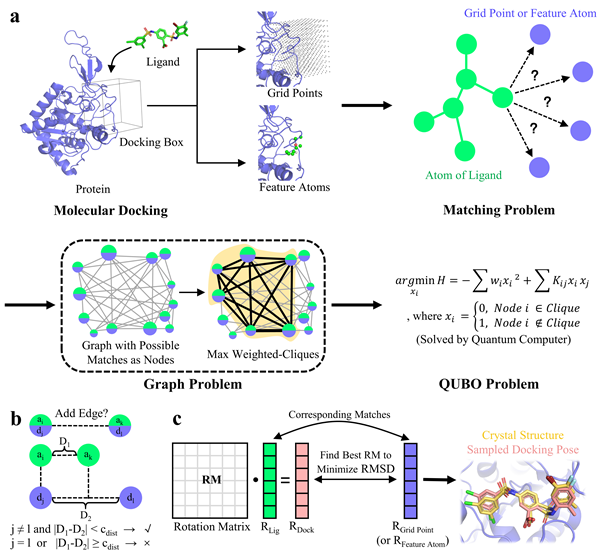

Recommended Configuration<p>
Python   <br>
PyQUBO   <br>
Prody    <br>
Numpy    <2 <br>
Scipy    1.10<br>
<br>
AutoDockFR should be downloaded and installed. Its "bin" path should be added to enviromental variables. AutoDockFR is at https://ccsb.scripps.edu/adfr/downloads/ 


Some Preparations

In [1]:
#!pip install PyQUBO
#!pip install Prody
#!pip install Scipy

In [2]:
#!pip install prody             

In [3]:
import os
here = os.getcwd()
if not os.path.exists("workdir_fam"):
    os.mkdir("workdir_fam")
if not os.path.exists("workdir_gpm"):
    os.mkdir("workdir_gpm")

Let's begin with Grid point matching. Run below. 

In [ ]:
import sys
sys.path.append("/home/allu786ansari/Qubo_Analysis/1_Code/QDock") #adjust the path


In [5]:
os.chdir("%s/workdir_fam"%(here))
from QDock.FeatureAtomMatching.qdock import FAMDock
fam = FAMDock()

1, Load protein file (in PDB format)

In [6]:
fam.make_receptor("../data/1y6r_protein.pdb")

adding gasteiger charges to peptide


2, Load ligand files to be docked

In [7]:
import shutil
ligand_li = [
  "1y6r_ligand.mol2",
  "2vkm_ligand.mol2",
  "3dxg_ligand.mol2",
  "2iwx_ligand.mol2",   
]

for i in ligand_li:
    shutil.copy("%s/%s"%("../data",i),"./%s"%(i))
#Well, it is a bug in AutoDockFR, that only ligand file at current dir could be processed.
    
fam.make_ligand(ligand_li)

1 molecule converted
@> 27 atoms and 1 coordinate set(s) were parsed in 0.00s.
1 molecule converted
@> 52 atoms and 1 coordinate set(s) were parsed in 0.00s.
1 molecule converted
@> 24 atoms and 1 coordinate set(s) were parsed in 0.00s.
1 molecule converted
@> 26 atoms and 1 coordinate set(s) were parsed in 0.00s.


3, Create the doxking box. There are two ways to create the docking box, either by the position of a ligand or give the corrdiante and length of the docking box.Here, the parameter "grid length" suggests the degree to discrete docking box. It is recomended to use 1.0 for "Feature Atom Matching" and 2.0 for "Grid Point Matching".

In [8]:
#!pip install numpy==1.24.4 scipy==1.10.1


In [9]:
#Via original ligand
fam.make_box_ligand("data/1y6r_ligand.mol2",grid_length=1.0)

#Via manual input of docking box(coordinates of the center and length in x,y,z dimension)
#fam.make_box_input(x=56.217,y=73.499,z=20.476,dx=10,dy=10,dz=10,grid_length=1.0)

1 molecule converted
@> 27 atoms and 1 coordinate set(s) were parsed in 0.00s.
@> 25 atoms and 1 coordinate set(s) were parsed in 0.00s.


#################################################################
# If you used AutoSite in your work, please cite:               #
#                                                               #
# Pradeep Anand Ravindranath and Michel F. Sanner               #
#                                                               #
# AutoSite: an automated approach for pseudoligands             #
# prediction - From ligand binding sites identification to      #
# predicting key ligand atoms                                   #
#                                                               #
# Bioinformatics (2016)                                         #
#                                                               #
# DOI: 10.1093/bioinformatics/btw367                            #
#                                                               #
# Please see http://adfr.scripps.edu/AutoDockFR/autosite.html   #
# for more information                                          #
##########

4,Docking. There are two docking modes. You could either dock a single ligand in thr ligand list made in step 2, or dock all ligandsin the ligand list. 

4.1, Dock a single ligand.<p> 
Explanation of parameters:<br>
    ligand: The ligand to be docked.<br>
    edge_cutoff: c_dist, the tolerance of geometry. 1.870 is recommended for Feature Atom Matching and 2.162 is recommended for Grid Point Matching<br>
    K_dist: Lagrange parameter maintaining geometry. 2.261 is recommended for Feature Atom Matching and 0.405 is recommended for Grid Point Matching<br>
    K_mono:  Lagrange parameter controling unique of matching 11.479 is recommended for Feature Atom Matching and 25.090 is recommended for Grid Point Matching<br>
    save_qubo: True (defalut) for saving the QUBO matrix. You could sent it to QCs.<br>
    sim_dock: True (default) to solve QUBO with a pyqubo simulator. If you switch it to False, then the function would stop when QUBO matrix is saved.<br>
    n_pose: number of poses to be sampled by simulator. default=30.<br>
    save_match: True (defalut) for saving the matching result.<br>
    save_pose: True (defalut) for saving the sampled poses (pdb file).<br>

In [10]:
poses1 = fam.indiv_dock(ligand=fam.ligands[0], edge_cutoff=1.870, K_dist=2.261, K_mono=11.479, n_pos=30, 
                       save_qubo=True,sim_dock=True,save_match=True,save_pose=True)
#numpy array

4.2, Dock multiple ligands. Parameters are the same as indiv_dock, while the ligand does not require an assignment, All ligand in the ligand list will be docked. 

In [11]:
poses2 = fam.dock(edge_cutoff=1.870, K_dist=2.261, K_mono=11.479, n_pos=30, 
                 save_qubo=True,sim_dock=True,save_match=True,save_pose=True)
#python list

5, Results

5.1, Poses. A numpy array containing coordinates of sampled poses.

In [12]:
print(type(poses1))
print(poses1.shape)
print(poses1[0])
print(type(poses2))
print(len(poses2))
print(poses2[1].shape)

<class 'numpy.ndarray'>
(30, 27, 3)
[[58.1475189  71.80518813 21.88269283]
 [58.63852246 72.63869335 20.78020041]
 [57.86171153 74.11183396 22.44519096]
 [58.15032504 72.69254259 23.1162001 ]
 [58.20476236 74.02624564 20.91056079]
 [58.28756065 72.26810706 19.91038571]
 [59.64601026 72.61164947 20.77510548]
 [57.04195234 74.23988114 19.9497165 ]
 [57.13189509 74.26640198 18.55656721]
 [55.95850146 74.46406741 17.92880391]
 [55.04773612 74.57068301 18.94132482]
 [55.78623169 74.52168332 16.91488501]
 [53.63146435 74.77551418 18.97980161]
 [55.68159293 74.44267365 20.19430892]
 [53.03340029 74.83044168 20.23031885]
 [53.76549645 74.69382533 21.35939997]
 [55.09993216 74.49489602 21.43938425]
 [52.88722007 74.90560546 17.87376061]
 [51.87071509 75.05168897 17.95108613]
 [53.33159778 74.85990664 16.94538672]
 [58.64638552 75.15907939 23.0891403 ]
 [59.57088257 74.96066938 23.00047988]
 [56.77288701 71.2827273  21.4657122 ]
 [56.04985171 70.05837858 22.5722831 ]
 [56.84172658 68.5539016  21

5.2, QUBO. A QUBO matrix (a python dict) saved in npy file. The QUBO matrix could be solved by QCs like D-WAVE amd CIM.

In [13]:
import numpy as np
qubo = np.load("QUBOs/1y6r_ligand.npy",allow_pickle=True).item()
print(list(qubo.keys())[0:10])
print(qubo[list(qubo.keys())[0]])

[('15_12_0.39000', '15_11_0.39000'), ('13_4_-0.50000', '9_21_0.34000'), ('18_1_-0.15000', '17_21_0.34000'), ('26_11_0.74000', '22_16_-0.15000'), ('24_12_0.39000', '19_21_-0.50000'), ('14_16_0.34000', '12_13_0.39000'), ('4_16_-0.15000', '1_0_-0.01000'), ('9_22_0.34000', '9_3_-0.01000'), ('12_5_-0.50000', '9_15_-0.10000'), ('21_21_-0.50000', '12_16_-0.15000')]
13.739999999999998


In [14]:
import numpy as np

# 1. Extract all unique variable labels from the dictionary keys
# PyQUBO keys are tuples like ('label1', 'label2')
labels_set = set()
for key_tuple in qubo.keys():
    labels_set.add(key_tuple[0])
    labels_set.add(key_tuple[1])

# 2. Sort labels to ensure they match the order of your QUBO matrix
# This is crucial for matching the 0s and 1s from your solution vector
qubo_labels = sorted(list(labels_set))

# 3. Save as a universal NumPy file for the other environment
np.save('qubo_variable_labels.npy', np.array(qubo_labels, dtype=object))

print(f"Extracted {len(qubo_labels)} unique labels.")
print("Sample labels:", qubo_labels[:5])


Extracted 675 unique labels.
Sample labels: ['0_0_-0.50000', '0_10_0.39000', '0_11_0.39000', '0_12_0.39000', '0_13_0.39000']


In [15]:
# Extract all unique variable names
all_vars = set()
for key in qubo.keys():
    if isinstance(key, tuple):
        all_vars.update(key)
    else:
        all_vars.add(key)

var_list = sorted(list(all_vars))
var_to_idx = {var: idx for idx, var in enumerate(var_list)}
n_vars = len(var_list)

print(f"Number of variables: {n_vars}")


Number of variables: 675


5.3, Results of sampling. (Red: Sampled Poses; Blue: Crystal Pose)
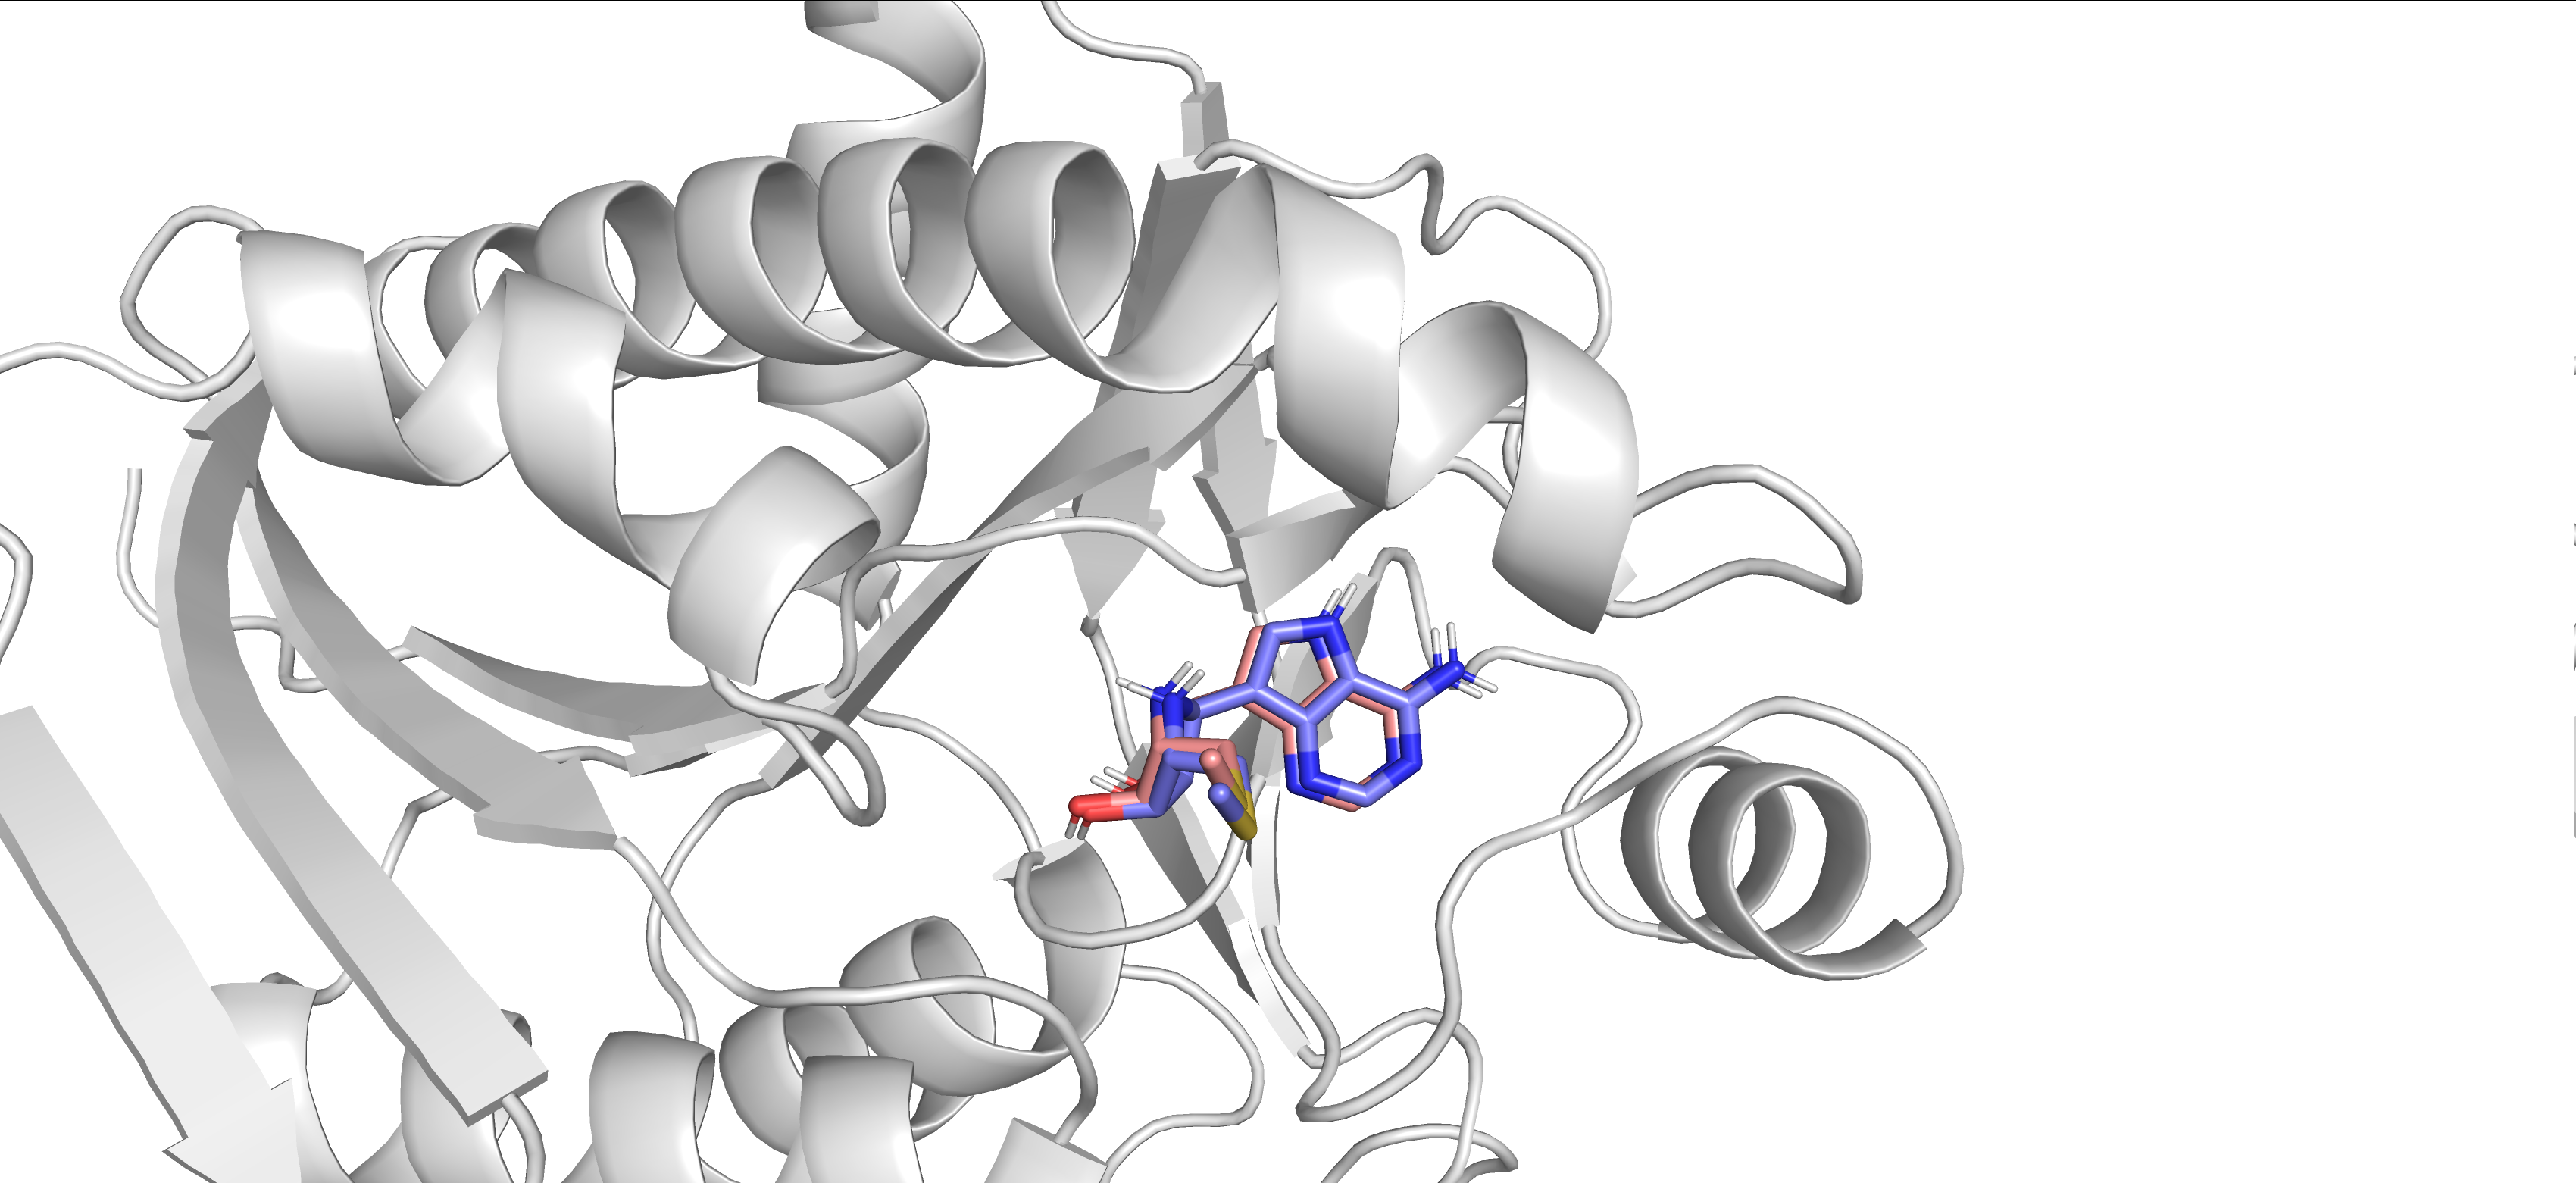
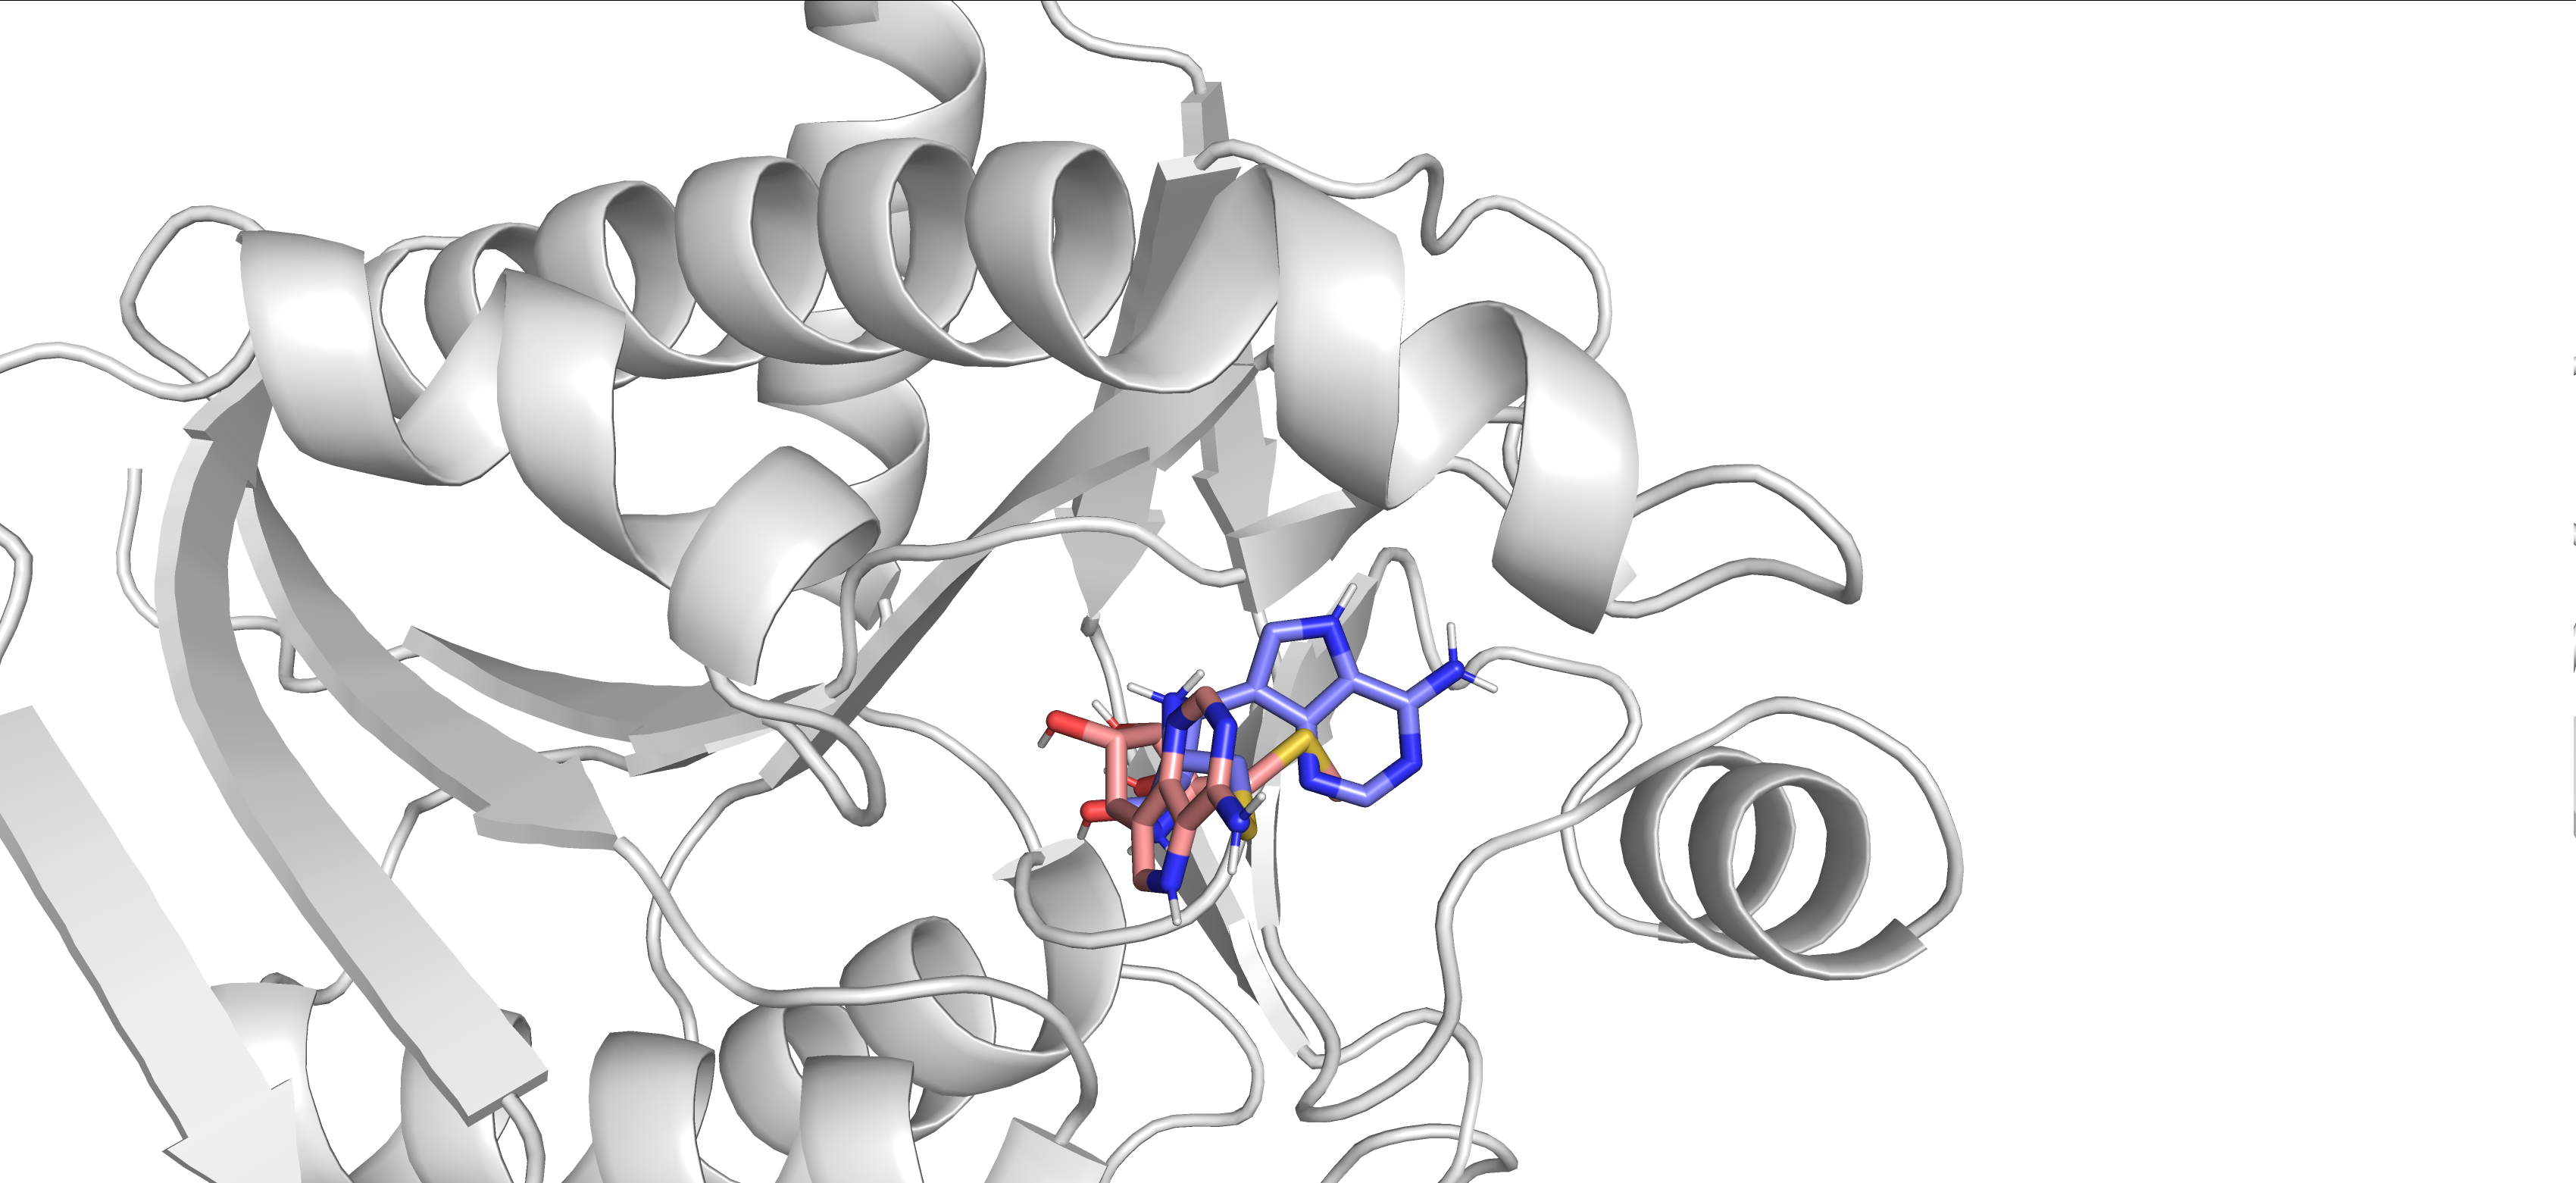
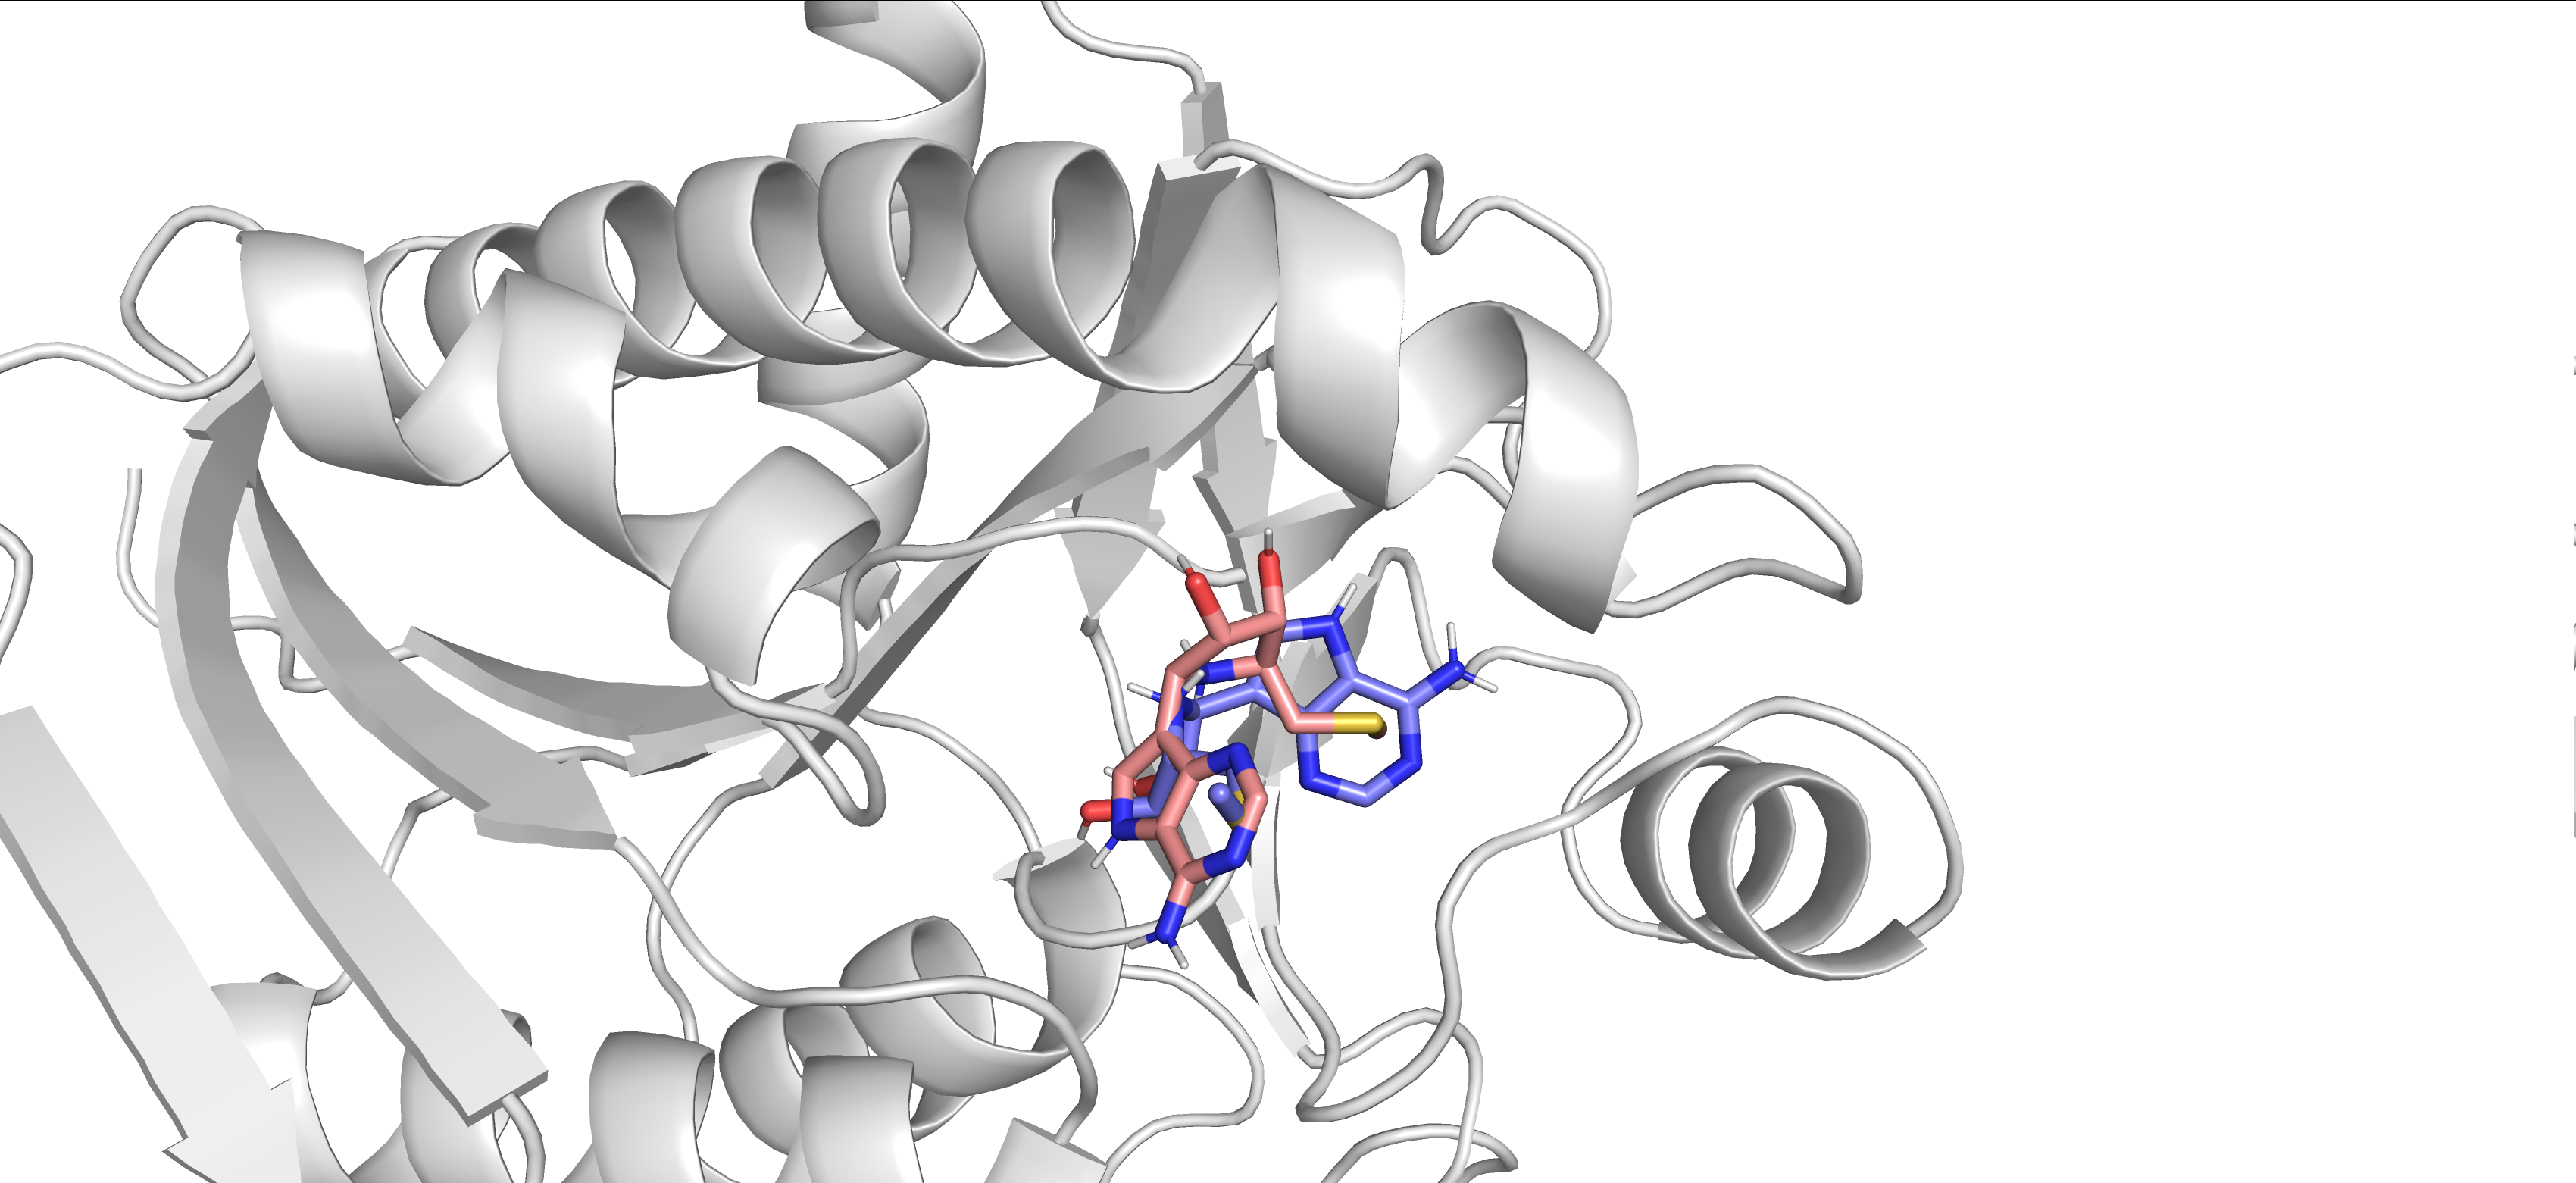

In [16]:
os.chdir("%s/workdir_gpm"%(here))
from QDock.GridPointMatching.qdock import GPMDock
import shutil

gpm = GPMDock()

print("Loading receptor and ligands...")
gpm.make_receptor("../data/1y6r_protein.pdb")

ligand_li = [
  "1y6r_ligand.mol2",
  "2vkm_ligand.mol2",
  "3dxg_ligand.mol2",
  "2iwx_ligand.mol2",   
]
for i in ligand_li:
    shutil.copy("%s/%s"%("../data",i),"./%s"%(i))
gpm.make_ligand(ligand_li)

print("Creating docking box...")
gpm.make_box_ligand("data/1y6r_ligand.mol2",grid_length=2.0)
#gpm.make_box_input(x=56.217,y=73.499,z=20.476,dx=10,dy=10,dz=10,grid_length=2.0)

print("Docking a single ligand...")
poses1 = gpm.indiv_dock(ligand=fam.ligands[0], edge_cutoff=2.162, K_dist=0.405, K_mono=25.090, n_pos=30, 
                       save_qubo=True,sim_dock=True,save_match=True,save_pose=True)
print("Docking all ligands...")
poses2 = gpm.dock(edge_cutoff=2.162, K_dist=0.405, K_mono=25.090, n_pos=30, 
                       save_qubo=True,sim_dock=True,save_match=True,save_pose=True)

print(type(poses1))
print(poses1.shape)
print(poses1[0])
print(type(poses2))
print(len(poses2))
print(poses2[1].shape)

import numpy as np
qubo = np.load("QUBOs/2iwx_ligand.npy",allow_pickle=True).item()

print(list(qubo.keys())[0:10])
print(qubo[list(qubo.keys())[0]])

# Extract all unique variable names
all_vars = set()
for key in qubo.keys():
    if isinstance(key, tuple):
        all_vars.update(key)
    else:
        all_vars.add(key)

var_list = sorted(list(all_vars))
var_to_idx = {var: idx for idx, var in enumerate(var_list)}
n_vars = len(var_list)

print(f"Number of variables: {n_vars}")


Loading receptor and ligands...
adding gasteiger charges to peptide


1 molecule converted
@> 27 atoms and 1 coordinate set(s) were parsed in 0.00s.
1 molecule converted
@> 52 atoms and 1 coordinate set(s) were parsed in 0.00s.
1 molecule converted
@> 24 atoms and 1 coordinate set(s) were parsed in 0.00s.
1 molecule converted
@> 26 atoms and 1 coordinate set(s) were parsed in 0.00s.


Creating docking box...


1 molecule converted
@> 27 atoms and 1 coordinate set(s) were parsed in 0.00s.


Docking a single ligand...
Docking all ligands...
<class 'numpy.ndarray'>
(30, 27, 3)
[[57.98717813 72.04270992 21.99654416]
 [58.45561693 72.61135277 20.72827155]
 [57.79793192 74.42518048 22.07854985]
 [58.07106692 73.16420759 23.01838156]
 [58.07129771 74.01200722 20.58367259]
 [58.05591458 72.08374162 19.96738357]
 [59.46060691 72.54416132 20.69264227]
 [56.87513435 74.06888507 19.64189389]
 [56.90537463 73.80443344 18.27119741]
 [55.71258645 73.91469199 17.65873483]
 [54.85033342 74.26329736 18.65926119]
 [55.49839668 73.76905757 16.66176875]
 [53.4441207  74.52730678 18.70537863]
 [55.53362696 74.3711356  19.88792341]
 [52.90283346 74.86205238 19.93803612]
 [53.67858682 74.9320931  21.04381821]
 [55.00839954 74.70146937 21.11523134]
 [52.65703241 74.45610844 17.62391073]
 [51.64987333 74.65492162 17.7058003 ]
 [53.05910582 74.2027693  16.70980228]
 [58.64198916 75.55082186 22.46274491]
 [59.55515195 75.30213658 22.3839328 ]
 [56.58017143 71.50017101 21.74667486]
 [55.86804796 70.

The way to use Grid Point Matching is almost the same as Feature Atom Matching